# 绥化市区 2004 年中考：为什么假设 N(533.5, 36.3²) + 629 分以上 N(579, 19²)？

文章里的两句话：

> 绥化市区 4923 名考生的中考分数在非高分段大致符合 **N(533.5, 36.3²)**；
> 我们假设绥化学生 **629 分及以上**大致符合 **N(579, 19²)**。

绥化没有大庆那样的逐分公布数据，所以这两个分布不是「拟合」出来的，而是「由少数几个节点**推**出来的」。
这个 notebook 把推导一步步算出来：

| | 依据 | 管什么 |
|---|---|---|
| 节点 ① | 绥化一中录取线 571 分、公费录取约 742 人 | 低、中段 |
| 节点 ② | 600 分以上 165 人 | 低、中段 |
| 假设 ③ | 大庆高分段「锐减」（σ 减半）在同一份试卷上也会出现；接缝处累计人数要连续 | 629 分以上 |

**先说结论的边界：** ①② 是两个实测节点，刚好定出两个参数（μ、σ），所以它们**不能互相检验**；③ 是类比大庆的**假设**，绥化 600 分以上没有逐分数据。

## 1 三个数字

- 绥化市区考生 **N = 4923**（见《绥化一中》资料整理）。
- **节点 ①**：绥化一中公费生录取线 **571 分**，公费招生约 **742 人** → 全市 ≥571 分的约有 742 人。
- **节点 ②**：**600 分以上 165 人**（苗丽萍校长访谈录，《绥化晚报》2006-06-18）。
- 另外：满分 690，和大庆**同一份试卷**（所以分数可直接比较，大庆的高分段形状也有参考价值）。

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'Hiragino Sans GB', 'Heiti TC', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

N = 4923                       # 绥化市区考生数
nodes = {571: 742, 600: 165}   # 分数门槛 → 全市 ≥ 该分的人数
pd.DataFrame({'分数 ≥': list(nodes), '人数': list(nodes.values()),
              '占全市 %': [round(100 * v / N, 2) for v in nodes.values()]}).set_index('分数 ≥').T

分数 ≥,571,600
人数,742.00,165.00
占全市 %,15.07,3.35


## 2 两个节点 → 一条正态曲线

若全市分数服从 N(μ, σ²)，则「≥ x 的人数 / N」= 1 − Φ((x−μ)/σ)。把节点的占比换成正态分位 z = Φ⁻¹(1 − 占比)：

$$ z_1=\Phi^{-1}\!\bigl(1-\tfrac{742}{4923}\bigr),\qquad z_2=\Phi^{-1}\!\bigl(1-\tfrac{165}{4923}\bigr) $$

于是 571 = μ + σ·z₁，600 = μ + σ·z₂，两个方程两个未知数，直接解：

$$ \sigma=\frac{600-571}{z_2-z_1},\qquad \mu=571-\sigma z_1 $$

In [2]:
(x1, n1), (x2, n2) = sorted(nodes.items())
z1, z2 = norm.isf(n1 / N), norm.isf(n2 / N)
sig_a = (x2 - x1) / (z2 - z1)
mu_a = x1 - sig_a * z1
print(f'z(571)={z1:.4f}（前 {100*n1/N:.1f}%），z(600)={z2:.4f}（前 {100*n2/N:.2f}%）')
print(f'σ = 29 / {z2 - z1:.4f} = {sig_a:.2f},  μ = {mu_a:.2f}   →  N({mu_a:.1f}, {sig_a:.1f}²)')

z(571)=1.0333（前 15.1%），z(600)=1.8315（前 3.35%）
σ = 29 / 0.7981 = 36.34,  μ = 533.45   →  N(533.5, 36.3²)


得到 **μ = 533.5，σ = 36.3**——正好是文章里的 N(533.5, 36.3²)。

**一个合理性检查：** 把这两个分位放到大庆 N(551, 34²) 里，看同一分位的分数差多少。

In [3]:
mu_d, sig_d = 551, 34       # 大庆 610–635 段拟合
rows = []
for x, n in nodes.items():
    z = norm.isf(n / N)
    rows.append({'分位': f'前 {100*n/N:.1f}%', '绥化分数': x, '大庆同分位分数': round(mu_d + sig_d * z, 1),
                 '大庆比绥化高': round(mu_d + sig_d * z - x, 1)})
pd.DataFrame(rows)

,分位,绥化分数,大庆同分位分数,大庆比绥化高
0,前 15.1%,571,586.1,15.1
1,前 3.4%,600,613.3,13.3


同一分位，大庆比绥化高约 13–15 分，与「总分上大庆平均比绥化市区高约 20 分」的大方向一致（μ 差 17.5）。
这只是**方向性**的印证：大庆那条曲线和绥化这条曲线不是独立的两个检验。

## 3 把这条正态向上外推，会出什么问题？

N(533.5, 36.3²) 只由 571、600 两个点定出，它在 600 分以上**没有任何数据约束**。直接外推，看看会预测什么：

In [4]:
sf_a = lambda x: N * norm.sf((x - mu_a) / sig_a)     # 单段正态外推
pd.DataFrame({'分数 ≥': [600, 610, 620, 630, 640, 650, 660],
              '单段外推人数': [round(sf_a(x), 1) for x in [600, 610, 620, 630, 640, 650, 660]]}).set_index('分数 ≥').T

分数 ≥,600,610,620,630,640,650,660
单段外推人数,165.0,86.5,42.4,19.4,8.3,3.3,1.2


单段外推说：650 分以上还有约 3 人，660 分以上约 1 人。**可是在大庆，同样的外推已经被证明偏高了**：
大庆 21500 人里，单段 N(551, 34²) 预测 ≥650 有 35 人，实测只有 8 人（见上一个 notebook）。
原因是 635 分之后人数衰减加速（σ 从 ≈34 降到 ≈19）。绥化考同一份卷子，尾部的天花板效应不会不存在。

所以我们需要在高分端**换一条更陡的曲线**。选择它时有两个要求：
1. 宽度 σ：借用大庆的 **σ = 19**（同一份试卷，天花板一样）；
2. 位置 μ：**在接缝处累计人数必须连续**——否则 629 分前后人数会无缘无故跳变。

## 4 「平滑过渡」到底是什么意思？

设接缝在 x₀。左边是 N(μₐ, σₐ²)，右边是 N(μ_b, 19²)。要求两边在 x₀ 的「≥x₀ 人数」相同：

$$ 1-\Phi\!\bigl(\tfrac{x_0-\mu_a}{\sigma_a}\bigr)=1-\Phi\!\bigl(\tfrac{x_0-\mu_b}{19}\bigr)
\;\Longrightarrow\; \mu_b=x_0-19\cdot\tfrac{x_0-\mu_a}{\sigma_a} $$

接缝取 629：

In [5]:
sig_b = 19
def join(x0, sig_b=sig_b):
    z0 = (x0 - mu_a) / sig_a
    return x0 - sig_b * z0           # 使累计人数连续的 μ_b

x0 = 629
mu_b = join(x0)
print(f'接缝 {x0} 分：z = {(x0-mu_a)/sig_a:.3f}，全市 ≥{x0} 约 {sf_a(x0):.1f} 人')
print(f'→ μ_b = {x0} − 19 × {(x0-mu_a)/sig_a:.3f} = {mu_b:.2f}   →  N({mu_b:.0f}, {sig_b}²)')

接缝 629 分：z = 2.630，全市 ≥629 约 21.0 人
→ μ_b = 629 − 19 × 2.630 = 579.04   →  N(579, 19²)


正好得到 **μ = 579**，即文章里的 N(579, 19²)。

为什么不能直接照搬大庆的 N(587, 19²)？因为大庆的 μ=587 是 21500 人那条曲线的位置；绥化整体比大庆低 15–20 分，
照搬会让 629 分处凭空多出一大批人。看下面的对比图就明白：

In [6]:
f_two = lambda x: np.where(np.asarray(x) <= x0, sf_a(x), N * norm.sf((np.asarray(x) - mu_b) / sig_b))
f_copy = lambda x: np.where(np.asarray(x) <= x0, sf_a(x), N * norm.sf((np.asarray(x) - 587) / sig_b))
print(f'接缝 629 分处，≥629 人数：左边（N(533.5,36.3²)）{sf_a(629):.1f}；'
      f'右边用 N(579,19²) {N*norm.sf((629-579)/19):.1f}；右边照搬大庆 N(587,19²) {N*norm.sf((629-587)/19):.1f}')

接缝 629 分处，≥629 人数：左边（N(533.5,36.3²)）21.0；右边用 N(579,19²) 20.9；右边照搬大庆 N(587,19²) 66.6


照搬大庆会在 629 分处凭空出现 ≈3 倍的人数（67 对 21），而 μ=579 使两边在 629 处相等——这就是「平滑过渡」。

## 5 出图

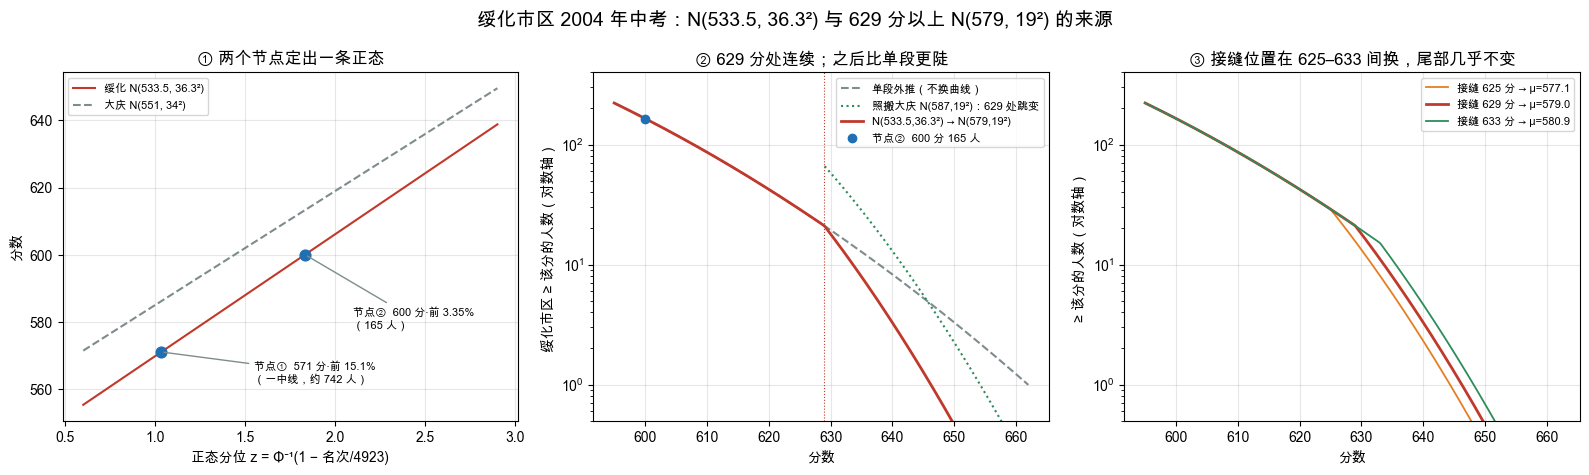

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.8))
BLUE, RED, GREY, ORG, GRN = '#1f6fb2', '#c0392b', '#7f8c8d', '#e67e22', '#2c8c5a'

# ① Q-Q：两个节点定一条直线，斜率 σ，截距 μ
a = ax[0]
zz = np.linspace(0.6, 2.9, 50)
a.plot(zz, mu_a + sig_a * zz, color=RED, label=f'绥化 N({mu_a:.1f}, {sig_a:.1f}²)')
a.plot(zz, mu_d + sig_d * zz, '--', color=GREY, label='大庆 N(551, 34²)')
a.scatter([z1, z2], [x1, x2], color=BLUE, s=60, zorder=3)
a.annotate('节点①  571 分·前 15.1%\n（一中线，约 742 人）', (z1, x1), (1.55, 562), fontsize=8, arrowprops=dict(arrowstyle='-', color=GREY))
a.annotate('节点②  600 分·前 3.35%\n（165 人）', (z2, x2), (2.1, 578), fontsize=8, arrowprops=dict(arrowstyle='-', color=GREY))
a.set_xlabel('正态分位 z = Φ⁻¹(1 − 名次/4923)'); a.set_ylabel('分数')
a.set_title('① 两个节点定出一条正态'); a.legend(fontsize=8, loc='upper left'); a.grid(alpha=.3)

# ② 尾部累计人数：单段外推 / 照搬大庆 / 连续接缝
a = ax[1]
x = np.linspace(595, 662, 300)
a.plot(x, sf_a(x), '--', color=GREY, label='单段外推（不换曲线）')
a.plot(x[x >= x0], N * norm.sf((x[x >= x0] - 587) / sig_b), ':', color=GRN, label='照搬大庆 N(587,19²)：629 处跳变')
a.plot(x, f_two(x), color=RED, lw=2, label=f'N(533.5,36.3²) → N({mu_b:.0f},19²)')
a.scatter([600], [165], color=BLUE, zorder=3, label='节点②  600 分 165 人')
a.axvline(x0, color=RED, ls=':', lw=.8)
a.set_yscale('log'); a.set_ylim(.5, 400)
a.set_xlabel('分数'); a.set_ylabel('绥化市区 ≥ 该分的人数（对数轴）')
a.set_title('② 629 分处连续；之后比单段更陡'); a.legend(fontsize=8); a.grid(alpha=.3)

# ③ 接缝位置的敏感度：625 / 629 / 633
a = ax[2]
for xj, col in [(625, ORG), (629, RED), (633, GRN)]:
    mj = join(xj)
    g = lambda t, xj=xj, mj=mj: np.where(np.asarray(t) <= xj, sf_a(t), N * norm.sf((np.asarray(t) - mj) / sig_b))
    a.plot(x, g(x), color=col, lw=2 if xj == 629 else 1.3, label=f'接缝 {xj} 分 → μ={mj:.1f}')
a.set_yscale('log'); a.set_ylim(.5, 400)
a.set_xlabel('分数'); a.set_ylabel('≥ 该分的人数（对数轴）')
a.set_title('③ 接缝位置在 625–633 间换，尾部几乎不变'); a.legend(fontsize=8); a.grid(alpha=.3)

fig.suptitle('绥化市区 2004 年中考：N(533.5, 36.3²) 与 629 分以上 N(579, 19²) 的来源', fontsize=14)
fig.tight_layout()
fig.savefig('2004年绥化市区中考正态假设的来源.png', dpi=150)
plt.show()

## 6 为什么是 629？——诚实的回答

接缝位置**不是数据定的**。上面的推导里，给定 σ=19 之后，不论接缝取在哪里，都能算出一个让累计人数连续的 μ_b；
629 只是其中一个选择（它碰巧让 μ_b 恰好是 579.0，一个整数）。下面看换接缝，结果会差多少：

In [8]:
rows = []
for xj in [625, 627, 629, 631, 633]:
    mj = join(xj)
    g = lambda t: sf_a(t) if t <= xj else N * norm.sf((t - mj) / sig_b)
    rows.append({'接缝': xj, 'μ_b': round(mj, 1), '≥625': round(g(625), 1), '≥630': round(g(630), 1),
                 '≥635': round(g(635), 1), '≥640': round(g(640), 1), '≥645': round(g(645), 1), '≥650': round(g(650), 1)})
pd.DataFrame(rows).set_index('接缝')

,μ_b,≥625,≥630,≥635,≥640,≥645,≥650
接缝,,,,,,,
625,577.1,28.9,13.3,5.7,2.3,0.9,0.3
627,578.1,28.9,15.5,6.7,2.8,1.1,0.4
629,579.0,28.9,18.0,7.9,3.3,1.3,0.5
631,580.0,28.9,19.4,9.3,3.9,1.5,0.6
633,580.9,28.9,19.4,10.9,4.6,1.8,0.7


接缝在 625–633 之间移动，≥630 在 13–19 人之间，≥640 在 2–5 人之间，≥650 都不到 1 人——**差别很小，而且都只涉及几个人**。
真正有影响的是 σ=19 这个假设和「接缝处连续」这个约束。

另一种选法是「让接缝对应大庆拐点的同一人数比例」：大庆 635 分处是全市前 0.6%，绥化前 0.6% ≈ 30 人，在 N(533.5, 36.3²) 里对应 ≈625 分；
文章取 629（前 0.43%、约 21 人），偏后 4 分。同样，这点差别对结果影响很小（见上表的 625 行）。

## 7 汇总：这套假设预测什么？

In [9]:
f = lambda t: float(sf_a(t)) if t <= x0 else float(N * norm.sf((t - mu_b) / sig_b))
out = pd.DataFrame({'分数 ≥': [600, 610, 620, 625, 630, 635, 640, 645, 650]})
out['两段（文章采用）'] = [round(f(t), 1) for t in out['分数 ≥']]
out['单段外推'] = [round(float(sf_a(t)), 1) for t in out['分数 ≥']]
out.set_index('分数 ≥').T

分数 ≥,600,610,620,625,630,635,640,645,650
两段（文章采用）,165.0,86.5,42.4,28.9,18.0,7.9,3.3,1.3,0.5
单段外推,165.0,86.5,42.4,28.9,19.4,12.8,8.3,5.3,3.3


这与文章里的估计吻合：≥620 约 42 人、≥625 约 30 人、≥630 约 19 人、≥635 约 8 人、≥640 约 4 人（模型在整数分上与文中取整结果差 ≤1–2 人）。

## 8 结论与边界

1. **N(533.5, 36.3²) 的来源**：节点 ① 571 分/742 人，节点 ② 600 分/165 人；两个节点正好定出 μ 和 σ。
2. **N(579, 19²) 的来源**：σ=19 借自大庆（同一份试卷，635 分后天花板压缩）；μ=579 由「629 分处累计人数与左边连续」解出。
3. **能说**：在 571–600 分这一窗口，N(533.5, 36.3²) 是两个实测节点的**精确内插**；
   在 629 分以上，两段的预测比单段外推更合理（外推会像大庆一样高估顶端）。
4. **不能说**：
   - 两个节点只够确定两个参数，**没有剩余数据来检验它们**；
   - 600 分以上、尤其 629 分以上，绥化**没有**逐分数据，σ=19 与接缝 629 都是假设；
   - 「165 人」「742 人」来自校长访谈与招生信息，口径是否完全一致（例如是否含外县、是否含体育 30 分）本身有不确定；
   - 这套分布只是描述绥化**市区**，县里（望奎、绥棱等）是另一个总体。